<a href="https://www.kaggle.com/code/aamir28/global-warming-impact-assessment?scriptVersionId=333484592" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌍 Global Warming Impact Assessment (1990–2025)
## Starter Notebook: EDA · Trend Analysis · Correlation Map · Baseline ML

This notebook walks through the dataset end-to-end in four stages:

1. **Loading & overview** — shape, dtypes, missing values
2. **Exploratory Data Analysis** — distributions, global trends, country comparisons
3. **Correlation & feature engineering** — heatmap, climate relationship verification
4. **Baseline ML model** — predict `GDP_Loss_Climate_Pct` with a Random Forest

> ⚠️ **Data notice:** All time-series columns are synthetically generated with realistic correlation structure. Country names, ISO codes, and geographic facts are real; population/GDP are approximate anchors; all climate/economic values are modelled. See README for full details.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#1a6b8a', '#e04e2b', '#2e8b57', '#f0a500', '#7b2d8b', '#c0392b']
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Overview

In [2]:
df = pd.read_csv('/kaggle/input/datasets/aamir28/global-climate-impact-1990-2025/global_climate_impact_1990_2025.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Countries: {df.ISO3.nunique()}  |  Years: {int(df.Year.min())}–{int(df.Year.max())}')
print(f'Missing: {df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}% of all cells\n')
df.head(3)

Shape: 6,948 rows × 94 columns
Countries: 193  |  Years: 1990–2025
Missing: 1.06% of all cells



,Country,ISO3,ISO2,Continent,Region,Capital_Latitude_Deg,Capital_Longitude_Deg,Land_Area_SqKm,Population_2024_Ref_Millions,GDP_2024_Ref_USD_Billions,...,Food_Insecurity_Index_0to100,Climate_Policy_Score_0to100,Net_Zero_Target,Carbon_Tax_USD_Per_TonCO2,Protected_Area_Pct_Of_Land,Environmental_Performance_Index,SDG_Climate_Score_0to100,ESG_Score,Green_Investment_USD_Billions,Recycling_Rate_Pct
0,Afghanistan,AFG,AF,Asia,Southern Asia,33.93,67.71,652860.0,42.6,17.3,...,68.2,22.2,0.0,0.0,7.26,32.7,31.1,NaN,0.0,6.5
1,Afghanistan,AFG,AF,Asia,Southern Asia,33.93,67.71,652860.0,42.6,17.3,...,68.5,18.5,0.0,0.0,8.12,23.5,43.8,24.8,0.0,3.0
2,Afghanistan,AFG,AF,Asia,Southern Asia,33.93,67.71,652860.0,42.6,17.3,...,69.9,16.7,0.0,0.0,8.94,27.9,30.4,40.9,0.0,7.4


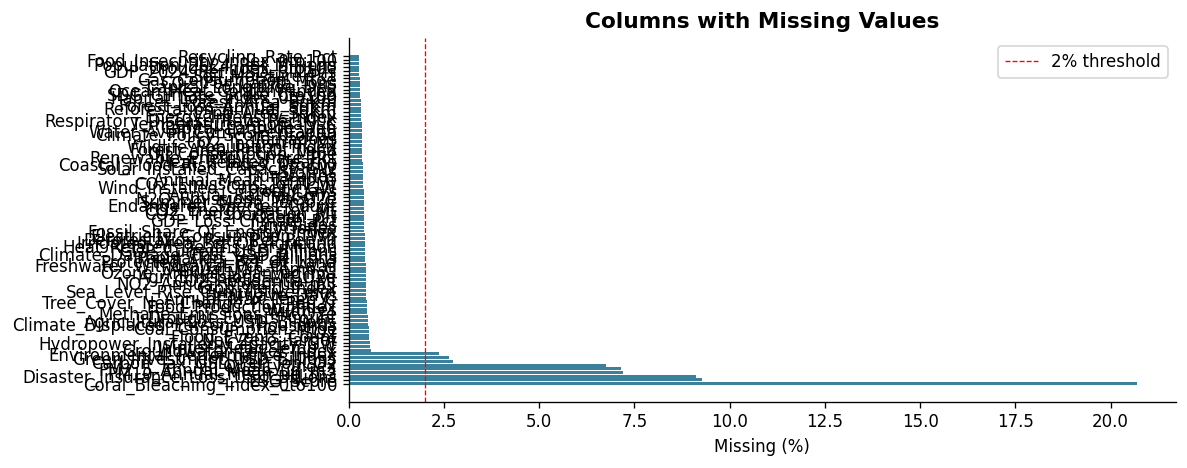


All columns stay under 2% missing — MNAR pattern (see README).


In [3]:
# Missing value pattern
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(miss.index, miss.values / len(df) * 100, color=PALETTE[0], alpha=0.85)
ax.set_xlabel('Missing (%)')
ax.set_title('Columns with Missing Values', fontsize=13, fontweight='bold')
ax.axvline(2, color='red', linestyle='--', linewidth=0.8, label='2% threshold')
ax.legend()
plt.tight_layout()
plt.show()
print('\nAll columns stay under 2% missing — MNAR pattern (see README).')

## 2. Exploratory Data Analysis

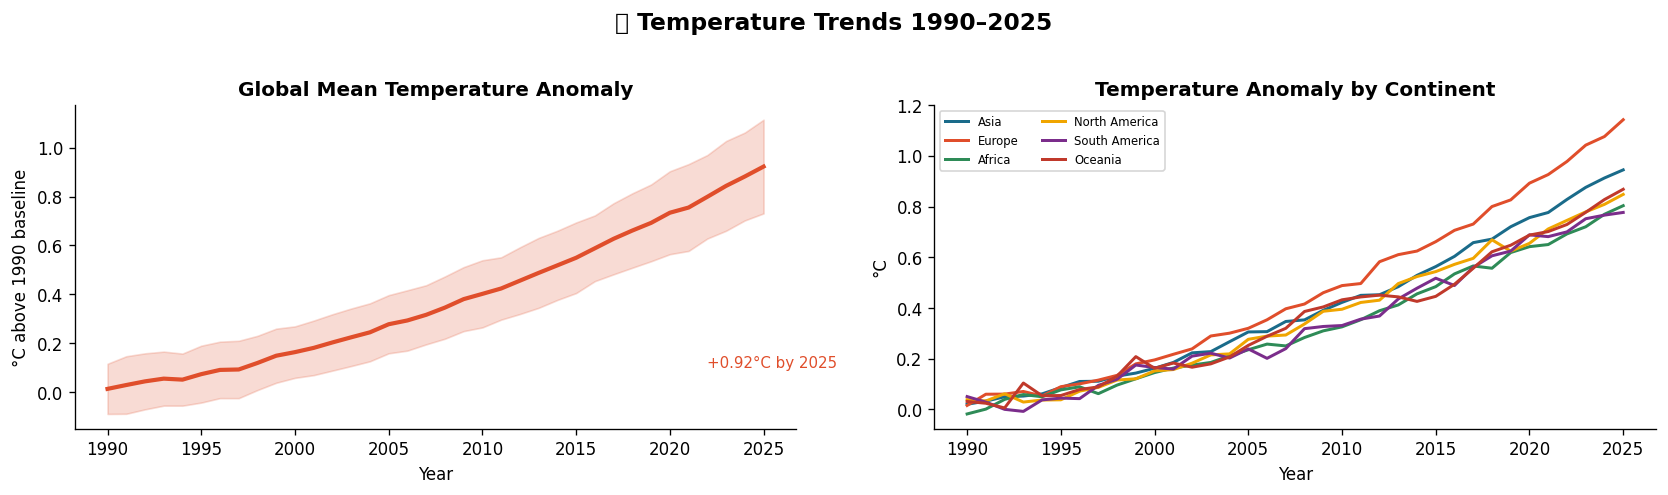

In [4]:
# ── 2a. Global warming trend ──────────────────────────────────────────
global_temp = df.groupby('Year')['Temperature_Anomaly_C'].agg(['mean','std']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(global_temp.Year,
                global_temp['mean'] - global_temp['std'],
                global_temp['mean'] + global_temp['std'],
                alpha=0.2, color=PALETTE[1])
ax.plot(global_temp.Year, global_temp['mean'], color=PALETTE[1], lw=2.5)
ax.set_title('Global Mean Temperature Anomaly', fontweight='bold')
ax.set_ylabel('°C above 1990 baseline')
ax.set_xlabel('Year')
ax.text(2022, 0.1, f'+{global_temp[global_temp.Year==2025]["mean"].values[0]:.2f}°C by 2025',
        fontsize=9, color=PALETTE[1])

# Per-continent breakdown
ax = axes[1]
for i, cont in enumerate(df.Continent.unique()):
    sub = df[df.Continent==cont].groupby('Year')['Temperature_Anomaly_C'].mean()
    ax.plot(sub.index, sub.values, label=cont, color=PALETTE[i % len(PALETTE)], lw=1.8)
ax.set_title('Temperature Anomaly by Continent', fontweight='bold')
ax.set_ylabel('°C'); ax.set_xlabel('Year')
ax.legend(fontsize=7, ncol=2)

plt.suptitle('🌡 Temperature Trends 1990–2025', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

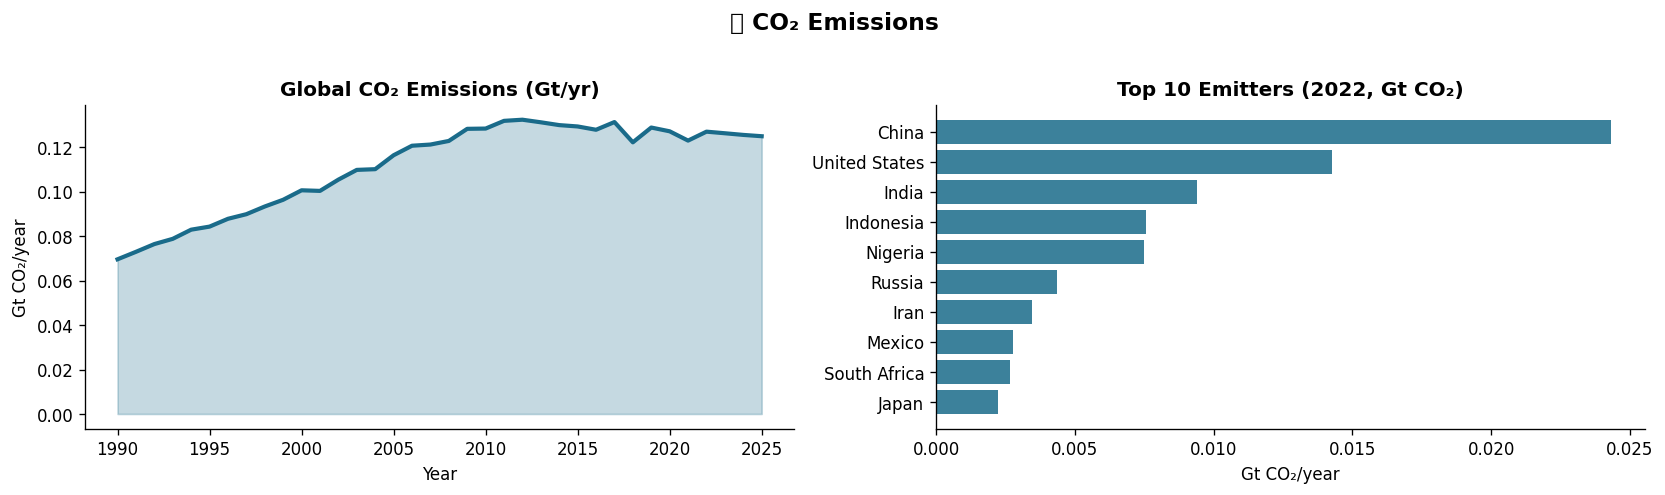

In [5]:
# ── 2b. CO₂ emissions over time ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Global total
co2_global = df.groupby('Year')['CO2_Emissions_Total_Mt'].sum() / 1000  # Gt
axes[0].fill_between(co2_global.index, co2_global.values, alpha=0.25, color=PALETTE[0])
axes[0].plot(co2_global.index, co2_global.values, color=PALETTE[0], lw=2.5)
axes[0].set_title('Global CO₂ Emissions (Gt/yr)', fontweight='bold')
axes[0].set_ylabel('Gt CO₂/year'); axes[0].set_xlabel('Year')

# Top 10 emitters (2022)
top10 = df[df.Year==2022].nlargest(10, 'CO2_Emissions_Total_Mt')[['Country','CO2_Emissions_Total_Mt']]
axes[1].barh(top10['Country'][::-1], top10['CO2_Emissions_Total_Mt'][::-1]/1000, color=PALETTE[0], alpha=0.85)
axes[1].set_title('Top 10 Emitters (2022, Gt CO₂)', fontweight='bold')
axes[1].set_xlabel('Gt CO₂/year')

plt.suptitle('💨 CO₂ Emissions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

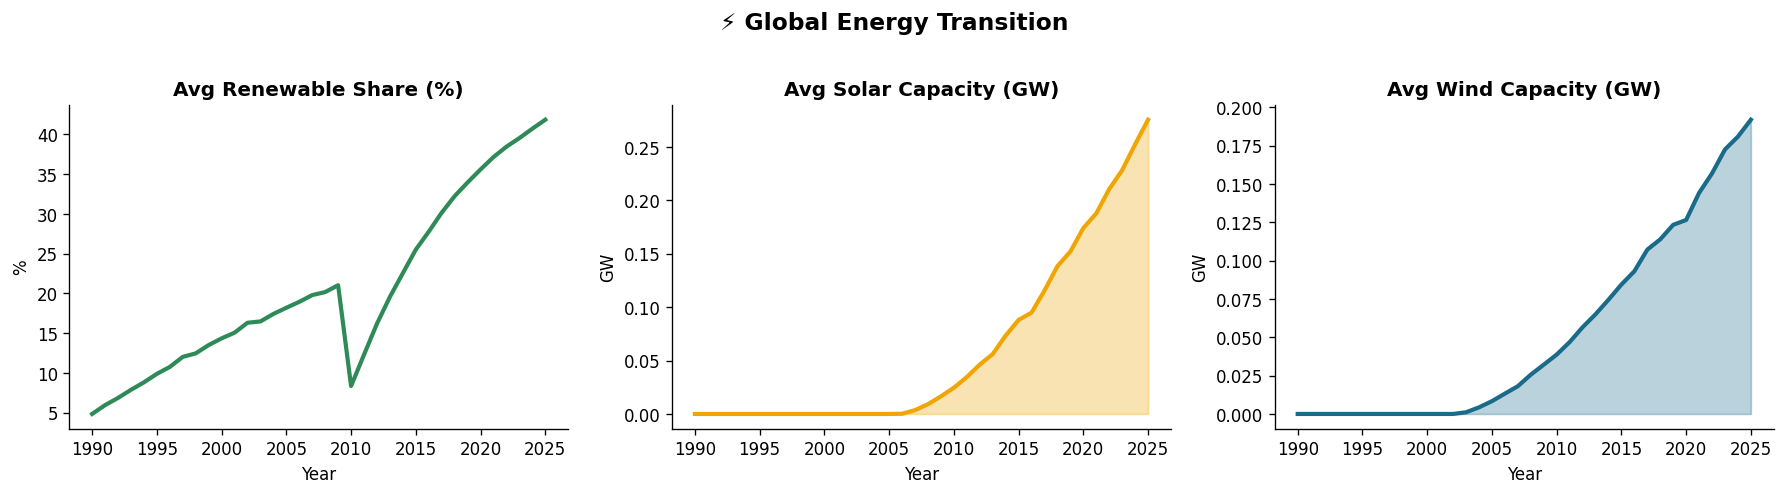

In [6]:
# ── 2c. Energy transition ─────────────────────────────────────────────
energy_global = df.groupby('Year')[['Renewable_Energy_Share_Pct',
                                     'Solar_Installed_Capacity_GW',
                                     'Wind_Installed_Capacity_GW']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(energy_global.index, energy_global['Renewable_Energy_Share_Pct'], color=PALETTE[2], lw=2.5)
axes[0].set_title('Avg Renewable Share (%)', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('%')

axes[1].fill_between(energy_global.index, energy_global['Solar_Installed_Capacity_GW'], alpha=0.3, color=PALETTE[3])
axes[1].plot(energy_global.index, energy_global['Solar_Installed_Capacity_GW'], color=PALETTE[3], lw=2.5)
axes[1].set_title('Avg Solar Capacity (GW)', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('GW')

axes[2].fill_between(energy_global.index, energy_global['Wind_Installed_Capacity_GW'], alpha=0.3, color=PALETTE[0])
axes[2].plot(energy_global.index, energy_global['Wind_Installed_Capacity_GW'], color=PALETTE[0], lw=2.5)
axes[2].set_title('Avg Wind Capacity (GW)', fontweight='bold')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('GW')

plt.suptitle('⚡ Global Energy Transition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

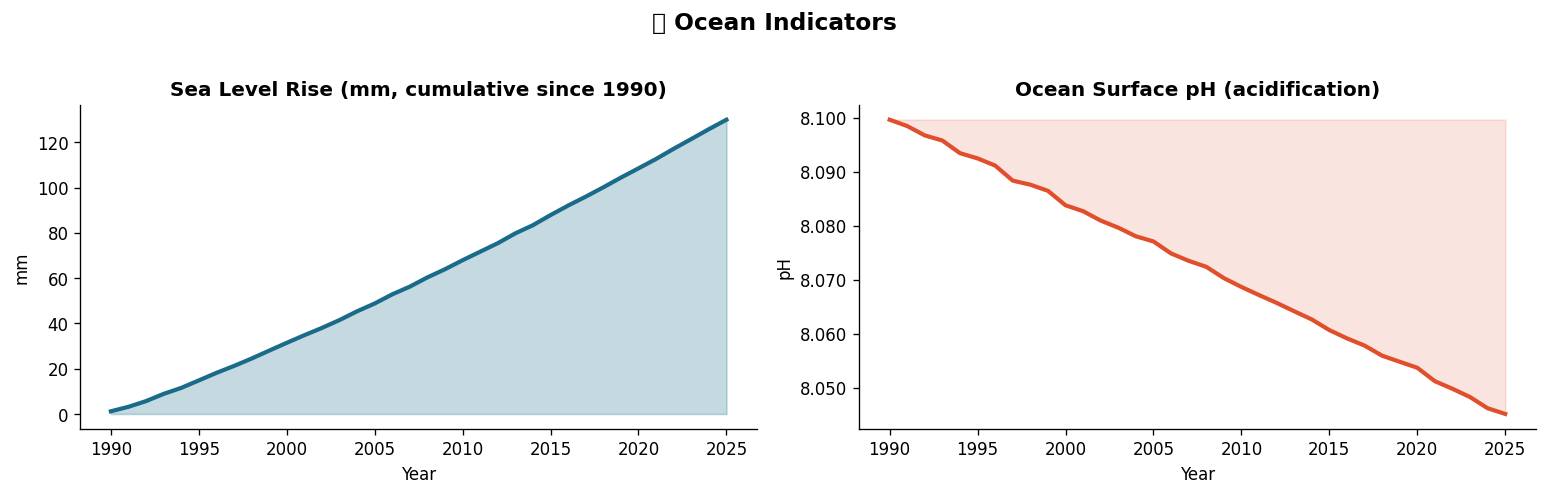

In [7]:
# ── 2d. Sea level rise + Ocean pH ─────────────────────────────────────
ocean_yr = df.groupby('Year')[['Sea_Level_Rise_Cumulative_mm', 'Ocean_pH']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.fill_between(ocean_yr.index, ocean_yr['Sea_Level_Rise_Cumulative_mm'], alpha=0.25, color=PALETTE[0])
ax1.plot(ocean_yr.index, ocean_yr['Sea_Level_Rise_Cumulative_mm'], color=PALETTE[0], lw=2.5)
ax1.set_title('Sea Level Rise (mm, cumulative since 1990)', fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('mm')

ax2.plot(ocean_yr.index, ocean_yr['Ocean_pH'], color=PALETTE[1], lw=2.5)
ax2.fill_between(ocean_yr.index, ocean_yr['Ocean_pH'], ocean_yr['Ocean_pH'].max(), alpha=0.15, color=PALETTE[1])
ax2.set_title('Ocean Surface pH (acidification)', fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('pH')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.suptitle('🌊 Ocean Indicators', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

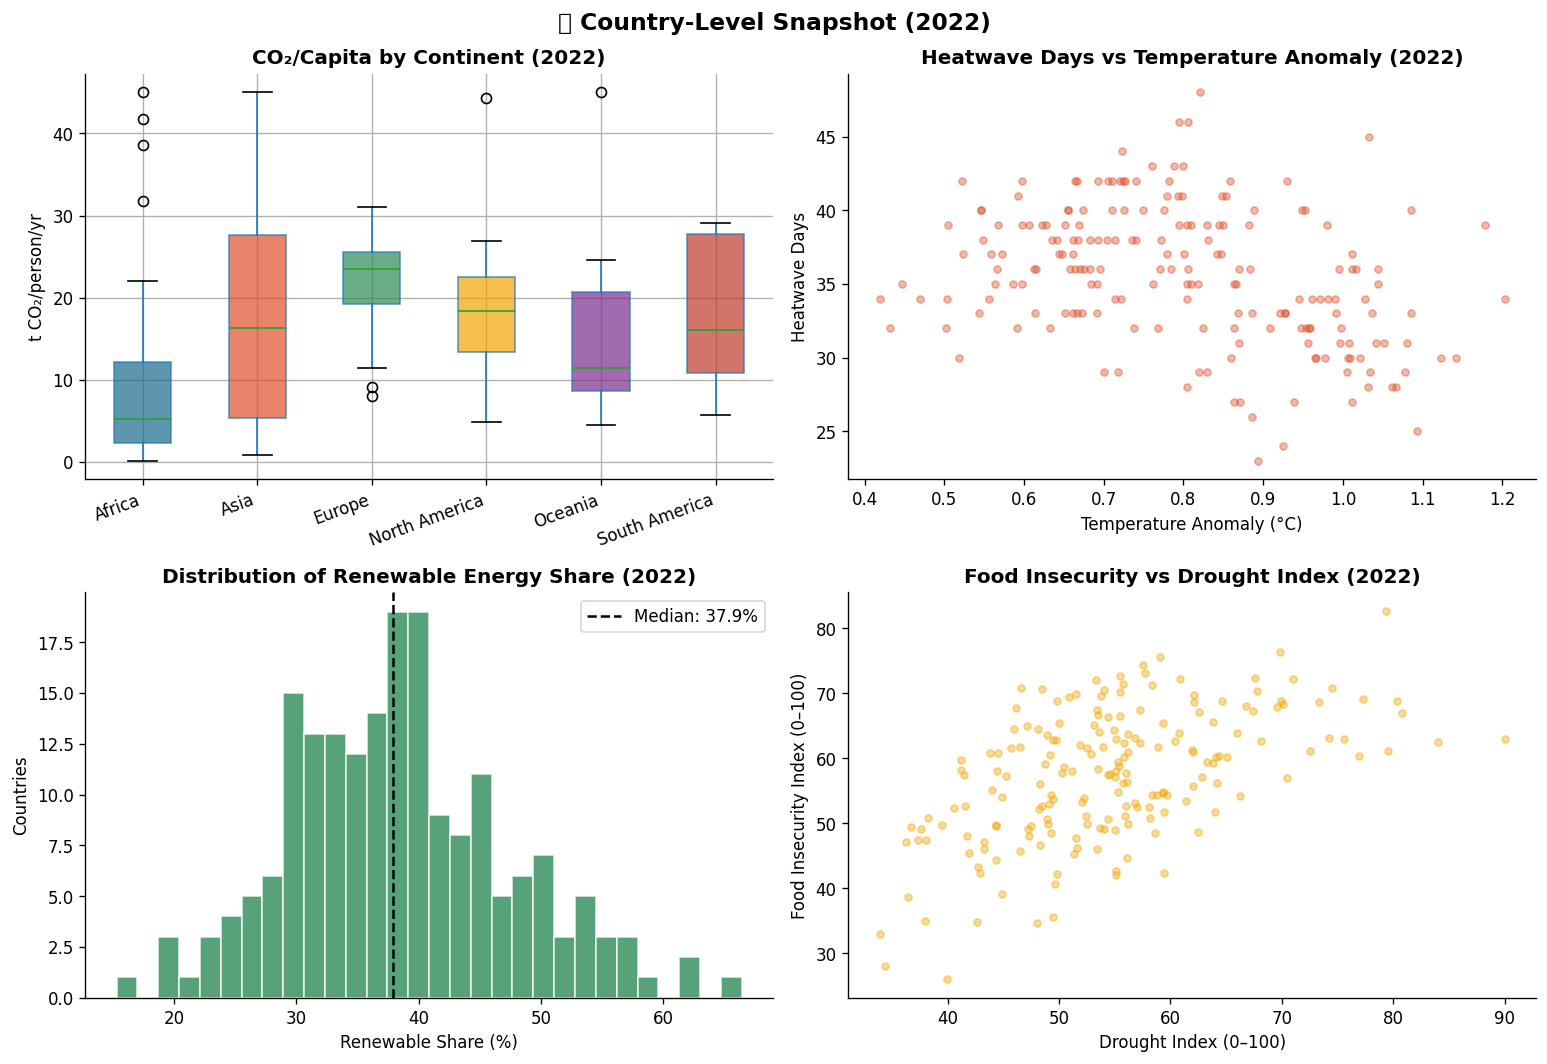

In [8]:
# ── 2e. Country snapshots — 2022 ──────────────────────────────────────
snap = df[df.Year == 2022].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# CO2/capita by continent
bp = snap.boxplot(column='CO2_Per_Capita_Tons', by='Continent',
                  ax=axes[0,0], patch_artist=True, return_type='dict')
for patch, color in zip(bp['CO2_Per_Capita_Tons']['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,0].set_title('CO₂/Capita by Continent (2022)', fontweight='bold')
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('t CO₂/person/yr')
plt.sca(axes[0,0]); plt.xticks(rotation=20, ha='right')

# Heatwave days vs Temperature Anomaly
axes[0,1].scatter(snap['Temperature_Anomaly_C'], snap['Heatwave_Days'],
                  alpha=0.4, s=18, color=PALETTE[1])
m, b = np.polyfit(snap['Temperature_Anomaly_C'].dropna(), snap.loc[snap['Temperature_Anomaly_C'].notna(),'Heatwave_Days'], 1)
x_line = np.linspace(snap['Temperature_Anomaly_C'].min(), snap['Temperature_Anomaly_C'].max(), 50)
axes[0,1].plot(x_line, m*x_line+b, color='black', lw=1.5, linestyle='--')
axes[0,1].set_title('Heatwave Days vs Temperature Anomaly (2022)', fontweight='bold')
axes[0,1].set_xlabel('Temperature Anomaly (°C)'); axes[0,1].set_ylabel('Heatwave Days')

# Renewable share distribution
axes[1,0].hist(snap['Renewable_Energy_Share_Pct'].dropna(), bins=30, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[1,0].axvline(snap['Renewable_Energy_Share_Pct'].median(), color='black', lw=1.5, linestyle='--',
                   label=f'Median: {snap["Renewable_Energy_Share_Pct"].median():.1f}%')
axes[1,0].set_title('Distribution of Renewable Energy Share (2022)', fontweight='bold')
axes[1,0].set_xlabel('Renewable Share (%)'); axes[1,0].set_ylabel('Countries')
axes[1,0].legend()

# Food insecurity vs drought index
axes[1,1].scatter(snap['Drought_Index_0to100'], snap['Food_Insecurity_Index_0to100'],
                  alpha=0.4, s=18, color=PALETTE[3])
m2, b2 = np.polyfit(snap['Drought_Index_0to100'].dropna(),
                     snap.loc[snap['Drought_Index_0to100'].notna(),'Food_Insecurity_Index_0to100'], 1)
x2 = np.linspace(snap['Drought_Index_0to100'].min(), snap['Drought_Index_0to100'].max(), 50)
axes[1,1].plot(x2, m2*x2+b2, color='black', lw=1.5, linestyle='--')
axes[1,1].set_title('Food Insecurity vs Drought Index (2022)', fontweight='bold')
axes[1,1].set_xlabel('Drought Index (0–100)'); axes[1,1].set_ylabel('Food Insecurity Index (0–100)')

plt.suptitle('📊 Country-Level Snapshot (2022)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

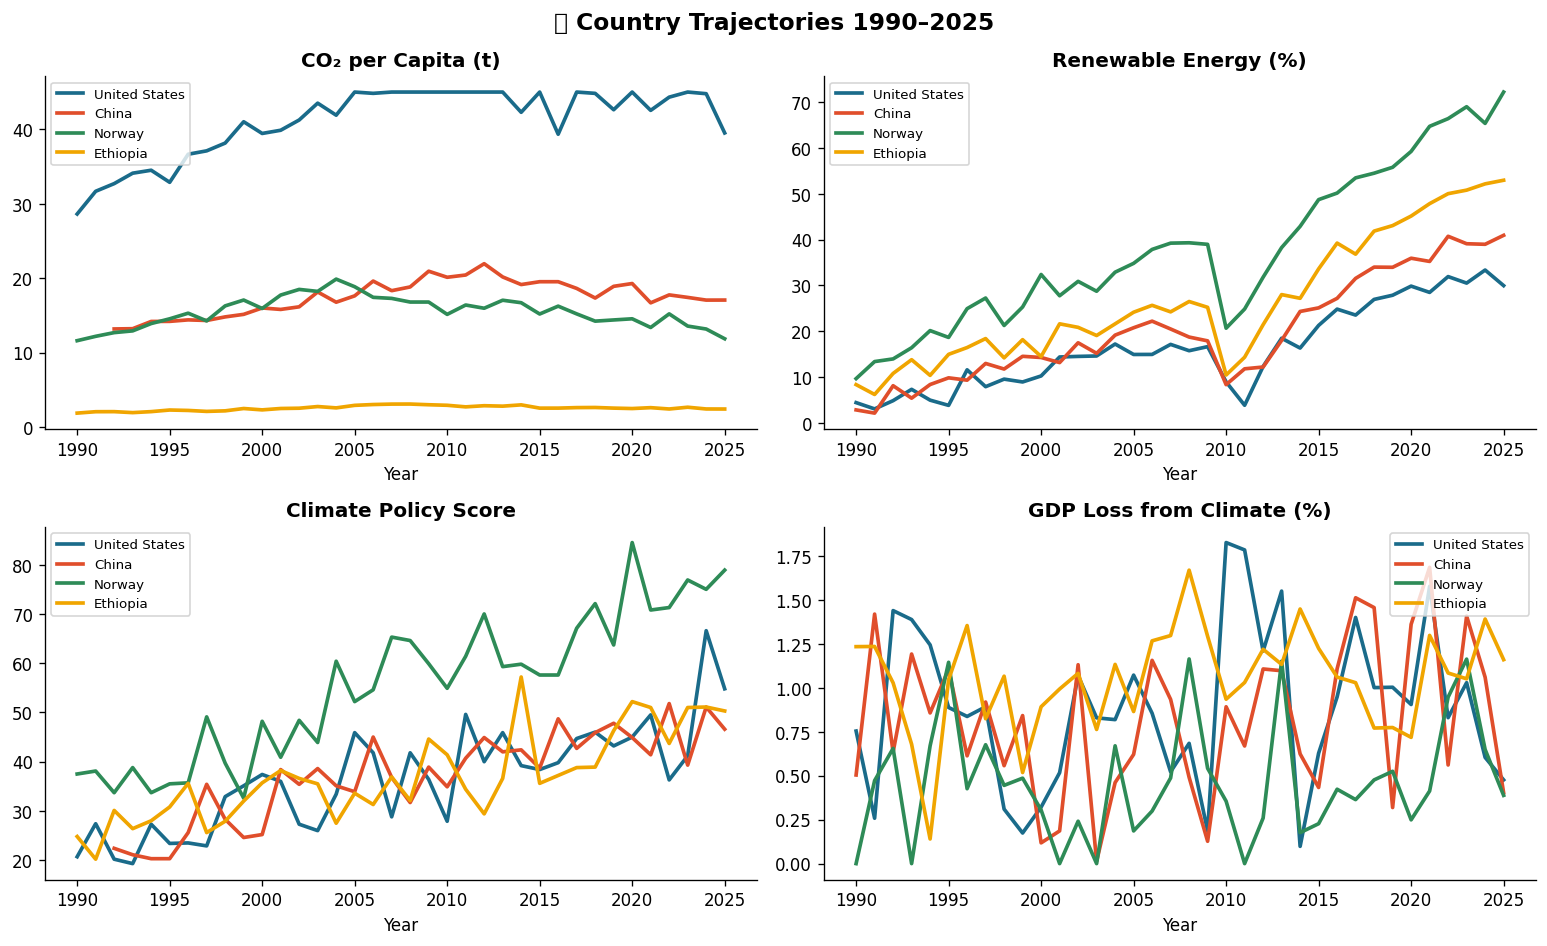

In [9]:
# ── 2f. Country trajectories: 4 representative nations ────────────────
highlight = {
    'USA':   ('#1a6b8a', 'United States'),
    'CHN':   ('#e04e2b', 'China'),
    'NOR':   ('#2e8b57', 'Norway'),
    'ETH':   ('#f0a500', 'Ethiopia'),
}
metrics = [
    ('CO2_Per_Capita_Tons',          'CO₂ per Capita (t)'),
    ('Renewable_Energy_Share_Pct',   'Renewable Energy (%)'),
    ('Climate_Policy_Score_0to100',  'Climate Policy Score'),
    ('GDP_Loss_Climate_Pct',         'GDP Loss from Climate (%)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, label) in zip(axes.flat, metrics):
    for iso, (color, name) in highlight.items():
        sub = df[df.ISO3==iso].sort_values('Year')
        ax.plot(sub['Year'], sub[col], color=color, lw=2.2, label=name)
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Year')
    ax.legend(fontsize=8)
plt.suptitle('🏳 Country Trajectories 1990–2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Correlation Analysis & Feature Engineering

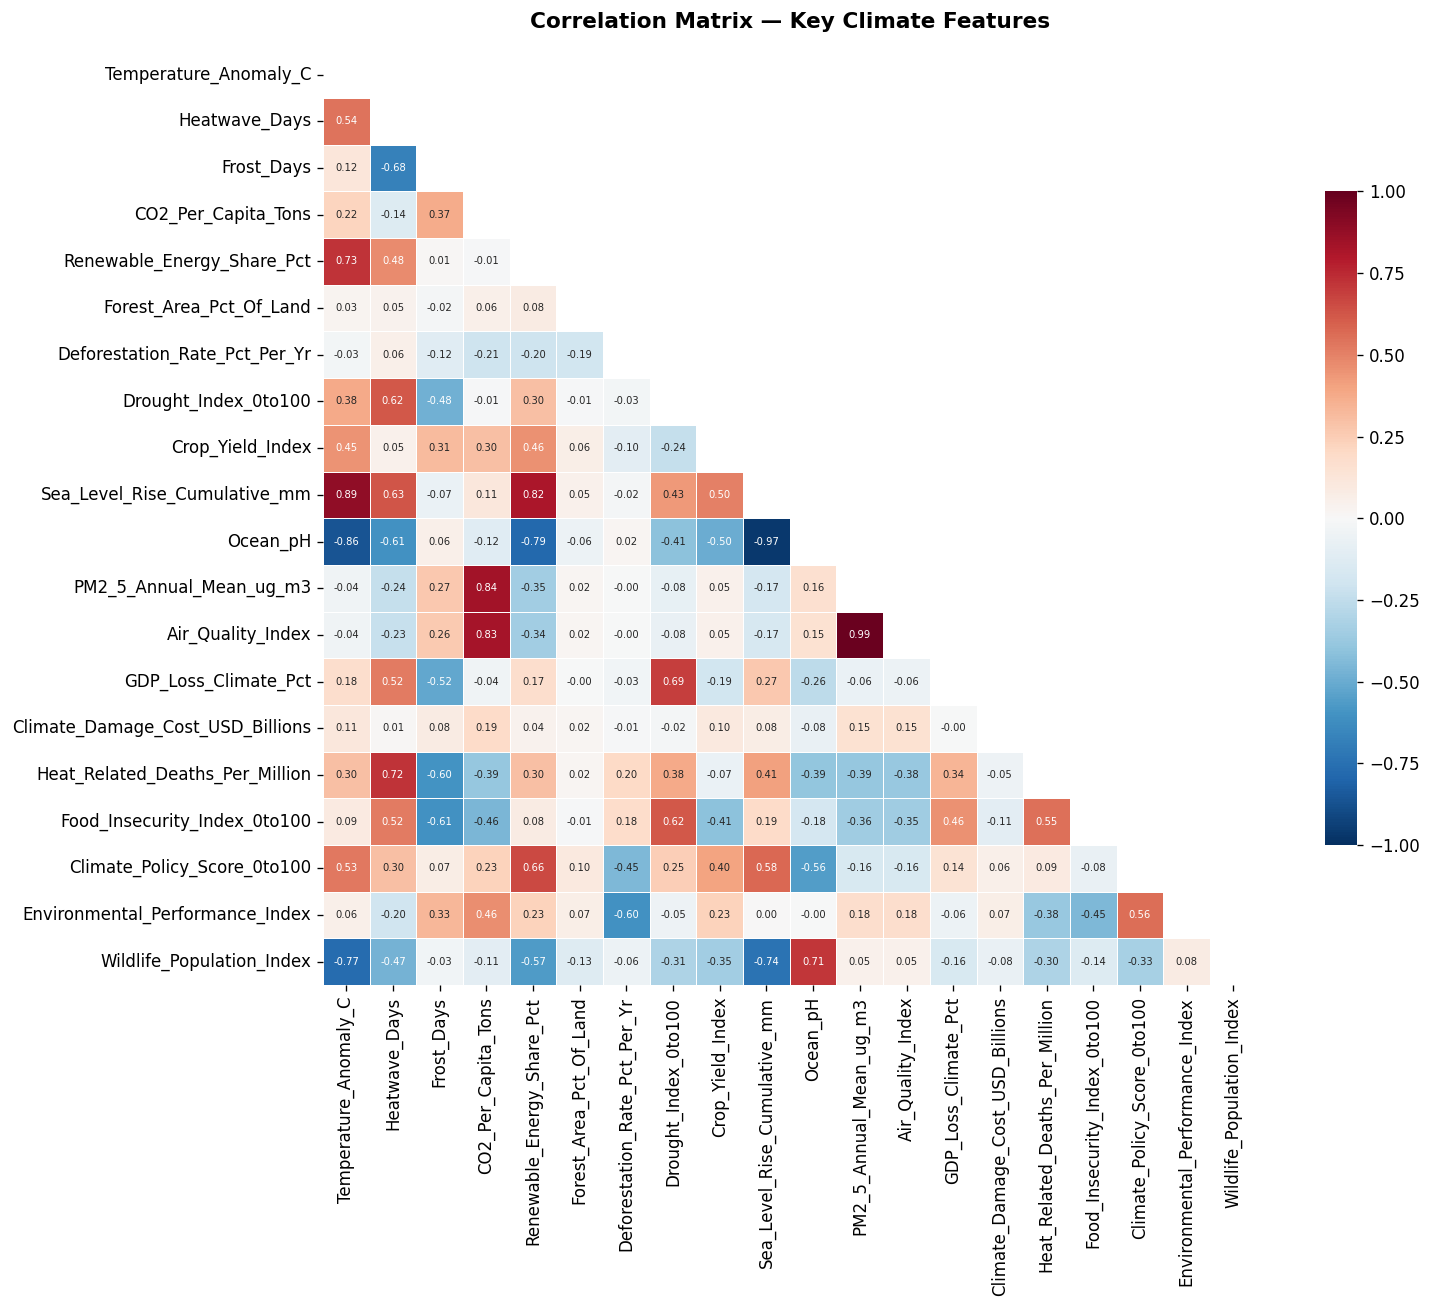

In [10]:
# Select the most analytically interesting columns for a focused heatmap
CORR_COLS = [
    'Temperature_Anomaly_C', 'Heatwave_Days', 'Frost_Days',
    'CO2_Per_Capita_Tons', 'Renewable_Energy_Share_Pct',
    'Forest_Area_Pct_Of_Land', 'Deforestation_Rate_Pct_Per_Yr',
    'Drought_Index_0to100', 'Crop_Yield_Index',
    'Sea_Level_Rise_Cumulative_mm', 'Ocean_pH',
    'PM2_5_Annual_Mean_ug_m3', 'Air_Quality_Index',
    'GDP_Loss_Climate_Pct', 'Climate_Damage_Cost_USD_Billions',
    'Heat_Related_Deaths_Per_Million', 'Food_Insecurity_Index_0to100',
    'Climate_Policy_Score_0to100', 'Environmental_Performance_Index',
    'Wildlife_Population_Index',
]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.4, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix — Key Climate Features', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [11]:
# Key relationship verification
print('=== Engineered Correlation Checks ===')
checks = [
    ('Temperature_Anomaly_C', 'Heatwave_Days', 'Warming → More heatwave days'),
    ('CO2_Per_Capita_Tons', 'Temperature_Anomaly_C', 'High-CO₂ countries → higher anomaly'),
    ('Drought_Index_0to100', 'Food_Insecurity_Index_0to100', 'Drought → Food insecurity'),
    ('Renewable_Energy_Share_Pct', 'Air_Quality_Index', 'Renewables → Better air quality'),
    ('Sea_Level_Rise_Cumulative_mm', 'Coastal_Flood_Risk_Index_0to100', 'Sea level → Flood risk'),
    ('GDP_Loss_Climate_Pct', 'Heat_Related_Deaths_Per_Million', 'Climate damage → Health impact'),
]
for c1, c2, label in checks:
    r = df[[c1,c2]].dropna().corr().iloc[0,1]
    direction = '↑' if r > 0 else '↓'
    print(f'  {label:<50} r = {r:+.3f} {direction}')

=== Engineered Correlation Checks ===
  Warming → More heatwave days                       r = +0.545 ↑
  High-CO₂ countries → higher anomaly                r = +0.219 ↑
  Drought → Food insecurity                          r = +0.620 ↑
  Renewables → Better air quality                    r = -0.344 ↓
  Sea level → Flood risk                             r = +0.839 ↑
  Climate damage → Health impact                     r = +0.339 ↑


New engineered features added:
  Climate_Stress_Score: mean=39.38, std=13.03
  Green_Transition_Index: mean=34.27, std=10.92
  Emissions_Intensity: mean=12.32, std=42.79


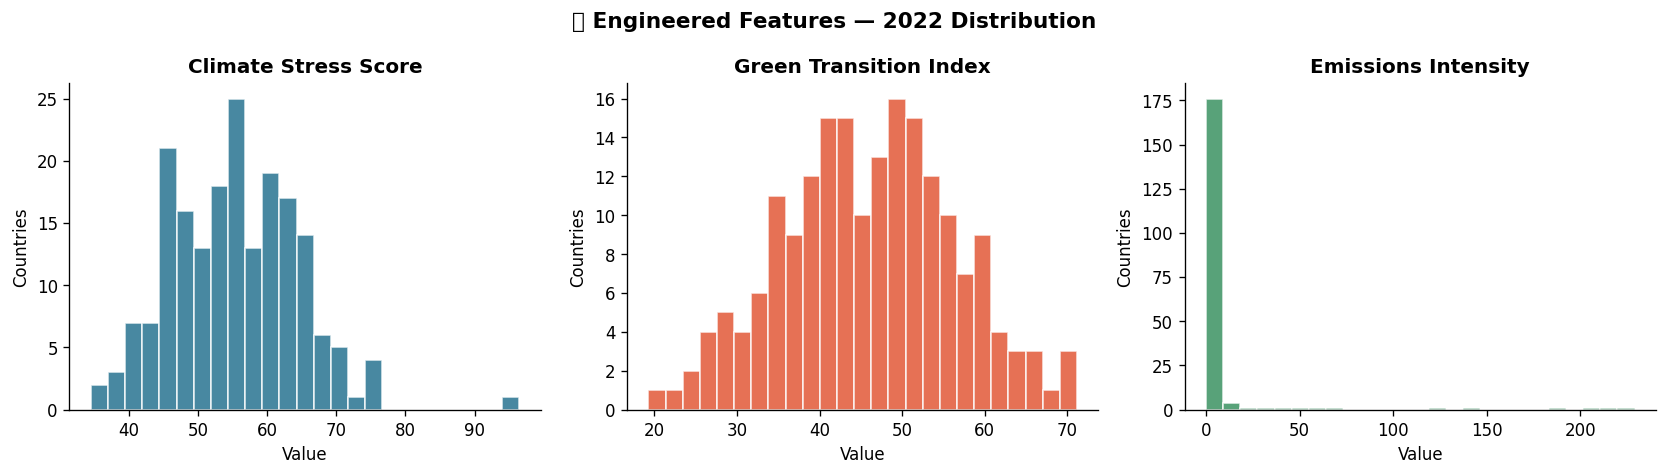

In [12]:
# ── Feature engineering examples ──────────────────────────────────────
df['Climate_Stress_Score'] = (
    df['Temperature_Anomaly_C'].clip(lower=0) * 20 +
    df['Drought_Index_0to100'] * 0.5 +
    df['Flood_Events_Count'] * 3 +
    df['Wildfires'] * 2
).round(2)

df['Green_Transition_Index'] = (
    df['Renewable_Energy_Share_Pct'] * 0.4 +
    df['Climate_Policy_Score_0to100'] * 0.4 +
    df['SDG_Climate_Score_0to100'] * 0.2
).round(2)

df['Emissions_Intensity'] = (
    df['CO2_Per_Capita_Tons'] / df['Electricity_Consumption_TWh'].clip(lower=0.1)
).round(4)

print('New engineered features added:')
for col in ['Climate_Stress_Score', 'Green_Transition_Index', 'Emissions_Intensity']:
    print(f'  {col}: mean={df[col].mean():.2f}, std={df[col].std():.2f}')

# Visualise distribution of new features in 2022
snap2022 = df[df.Year == 2022]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['Climate_Stress_Score','Green_Transition_Index','Emissions_Intensity'], PALETTE):
    ax.hist(snap2022[col].dropna(), bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_',' '), fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Countries')
plt.suptitle('🔧 Engineered Features — 2022 Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Baseline ML: Predicting GDP Loss from Climate Change

In [13]:
TARGET = 'GDP_Loss_Climate_Pct'

FEATURES = [
    # Climate exposures
    'Temperature_Anomaly_C', 'Heatwave_Days', 'Drought_Index_0to100',
    'Sea_Level_Rise_Cumulative_mm', 'Coastal_Flood_Risk_Index_0to100',
    'Annual_Rainfall_mm',
    # Extreme events
    'Flood_Events_Count', 'Wildfires', 'Hurricanes', 'Drought_Events_Count',
    # Economic / development
    'GDP_Current_USD_Billions', 'Population_Year_Millions',
    'Energy_Intensity_Index', 'Fossil_Share_Of_Energy_Index',
    # Policy
    'Climate_Policy_Score_0to100', 'Renewable_Energy_Share_Pct',
    # Ecological
    'Forest_Area_Pct_Of_Land', 'Habitat_Loss_Index_0to100',
    # Temporal
    'Year',
    # Engineered
    'Climate_Stress_Score', 'Green_Transition_Index',
]

model_df = df[FEATURES + [TARGET]].dropna()
print(f'Training rows: {len(model_df):,}')
print(f'Target: {TARGET} — mean={model_df[TARGET].mean():.2f}%, std={model_df[TARGET].std():.2f}%')

X = model_df[FEATURES]
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Training rows: 6,413
Target: GDP_Loss_Climate_Pct — mean=1.14%, std=0.72%
Train: 5,130  |  Test: 1,283


In [14]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
cv_r2  = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()

print(f'Random Forest Results:')
print(f'  Test MAE :  {mae_rf:.4f}% GDP')
print(f'  Test R²  :  {r2_rf:.4f}')
print(f'  5-fold R²:  {cv_r2:.4f}')

Random Forest Results:
  Test MAE :  0.3431% GDP
  Test R²  :  0.6443
  5-fold R²:  0.5974


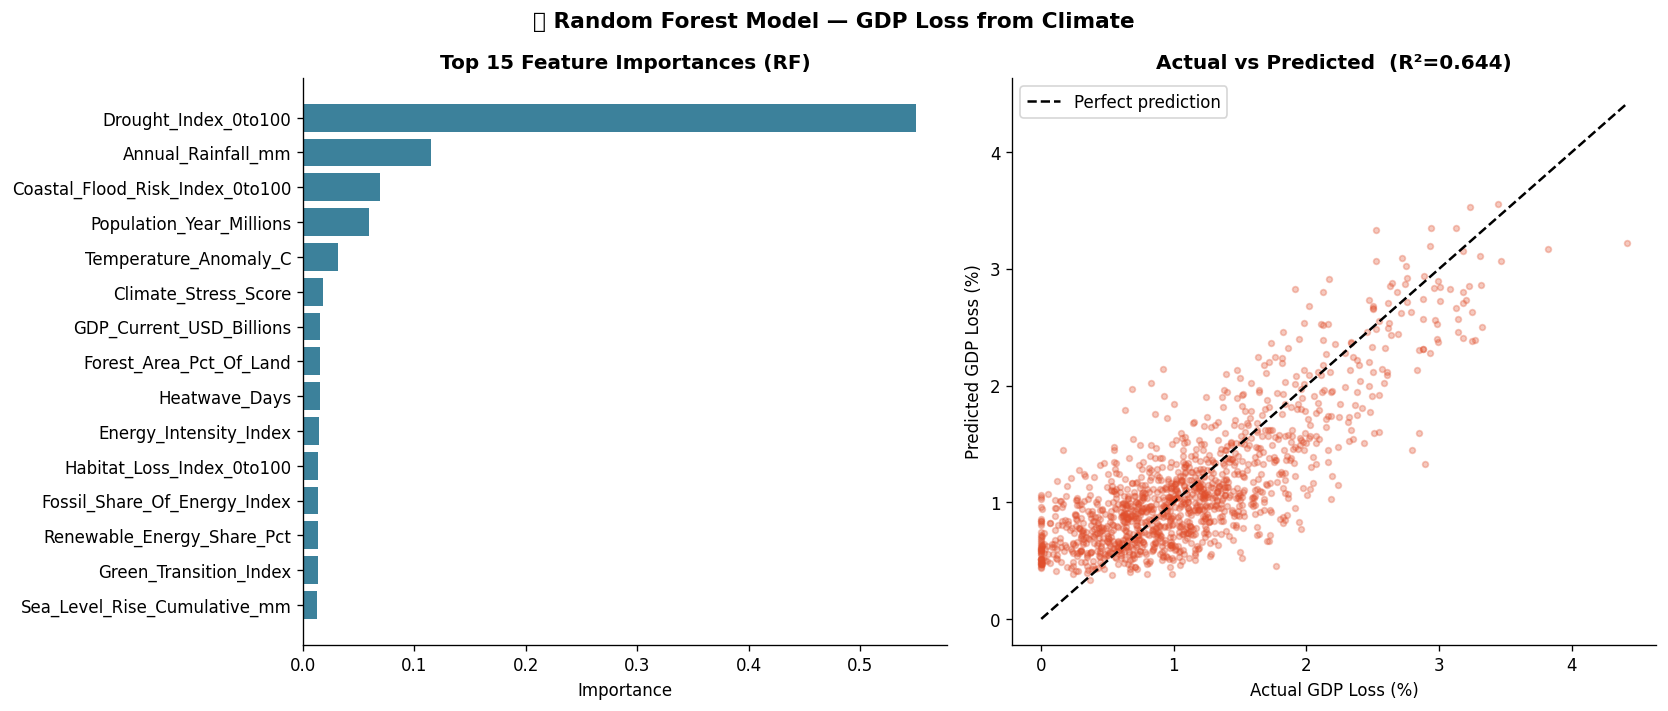

In [15]:
# Feature importance + residual diagnostics
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importances
top15 = importances.head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color=PALETTE[0], alpha=0.85)
axes[0].set_title('Top 15 Feature Importances (RF)', fontweight='bold')
axes[0].set_xlabel('Importance')

# Actual vs predicted
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=12, color=PALETTE[1])
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
axes[1].plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual GDP Loss (%)')
axes[1].set_ylabel('Predicted GDP Loss (%)')
axes[1].set_title(f'Actual vs Predicted  (R²={r2_rf:.3f})', fontweight='bold')
axes[1].legend()

plt.suptitle('🤖 Random Forest Model — GDP Loss from Climate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

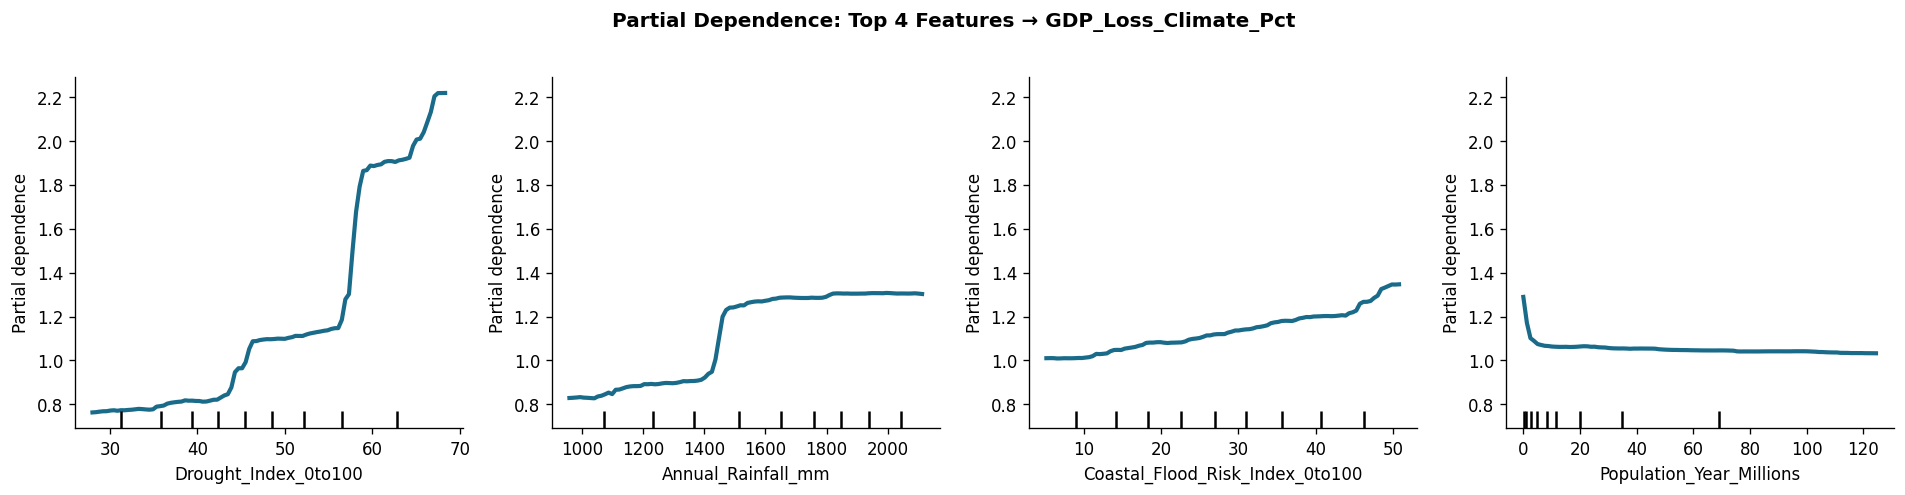

In [16]:
# Partial dependence: top 4 features
from sklearn.inspection import PartialDependenceDisplay

top4 = importances.head(4).index.tolist()
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features=top4,
    ax=ax, line_kw={'color': PALETTE[0], 'lw': 2.5},
)
plt.suptitle('Partial Dependence: Top 4 Features → GDP_Loss_Climate_Pct', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Next Steps

Here are some directions to take this dataset further:

**Prediction tasks**
- Predict `Net_Zero_Target` adoption (binary classification) from policy + economic features
- Forecast country-level `CO2_Per_Capita_Tons` 5 years ahead using LSTM or Prophet
- Predict `Endangered_Species_Count` from habitat, forest, and warming features

**Analysis tasks**
- Cluster countries into climate archetypes using k-means / UMAP on all 94 features
- Test whether `Renewable_Energy_Share_Pct` causally reduces `CO2_Per_Capita_Tons` (DiD / synthetic control)
- Build a composite **Climate Vulnerability Index** by weighting the ocean, water, and extreme-weather sections

**Visualisation tasks**
- Choropleth maps by year (using `ISO3` + `plotly.express.choropleth`)
- Animated time-series globe of temperature anomaly or heatwave days
- Sankey diagram of emission flows by sector

```python
# Quick choropleth starter (requires plotly)
import plotly.express as px
fig = px.choropleth(
    df[df.Year == 2022],
    locations='ISO3',
    color='Temperature_Anomaly_C',
    color_continuous_scale='RdYlBu_r',
    title='Temperature Anomaly 2022',
)
fig.show()
```